# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

                     **firstly i upload the liberies like pandas and numpy** 
                                         **upload the data** 


In [37]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns


In [38]:
data = pd.read_csv("/kaggle/input/glassdoor-data/glassdoor_jobs - 13.csv") 


In [39]:
data.describe()

,Rating,Founded
count,1000.000000,1000.000000
mean,3.581300,1650.801000
std,1.323818,741.158672
min,-1.000000,-1.000000
25%,3.400000,1920.750000
50%,3.800000,1995.000000
75%,4.300000,2008.000000
max,5.000000,2019.000000


In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          1000 non-null   object 
 1   Salary Estimate    1000 non-null   object 
 2   Job Description    1000 non-null   object 
 3   Rating             1000 non-null   float64
 4   Company Name       1000 non-null   object 
 5   Location           1000 non-null   object 
 6   Headquarters       1000 non-null   object 
 7   Size               1000 non-null   object 
 8   Founded            1000 non-null   int64  
 9   Type of ownership  1000 non-null   object 
 10  Industry           1000 non-null   object 
 11  Sector             1000 non-null   object 
 12  Revenue            1000 non-null   object 
 13  Competitors        1000 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 109.5+ KB


In [41]:
data.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,Data Scientist,$77K-$92K (Glassdoor Est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"
1,Data Scientist,$77K-$92K (Glassdoor Est.),"Secure our Nation, Ignite your Future\n\nSumma...",4.1,ManTech\n4.1,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,₹100 to ₹500 billion (INR),-1
2,Data Scientist,$77K-$92K (Glassdoor Est.),"By clicking the Apply button, I understand tha...",3.7,Takeda\n3.7,"Cambridge, MA","OSAKA, Japan",10000+ employees,1781,Company - Public,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,₹500+ billion (INR),"Novartis, Baxter, Pfizer"
3,Data Scientist,$77K-$92K (Glassdoor Est.),Join Our Growing Team\nA career with A Place f...,3.0,A Place for Mom\n3.0,"Overland Park, KS","New York, NY",501 to 1000 employees,2000,Company - Private,Healthcare Services & Hospitals,Healthcare,Unknown / Non-Applicable,"Enlivant, Sunrise Senior Living, Brookdale Sen..."
4,Data Scientist,$77K-$92K (Glassdoor Est.),We are looking for Data Scientists who are int...,3.7,GovTech\n3.7,"San Francisco, CA","Singapore, Singapore",1001 to 5000 employees,2016,Government,Government Agencies,Government,Unknown / Non-Applicable,-1


In [42]:
data.isnull().sum()

Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
dtype: int64

                                  **first colums that need to edit : salary estimate**

In [43]:
data['Salary Estimate'].dtype

dtype('O')

In [44]:
data['Salary Estimate'].value_counts()


Salary Estimate
$105K-$138K (Glassdoor Est.)          130
$108K-$140K (Glassdoor Est.)           30
$59K-$101K (Glassdoor Est.)            30
$81K-$137K (Glassdoor Est.)            30
$81K-$102K (Glassdoor Est.)            30
$60K-$124K (Glassdoor Est.)            30
$71K-$108K (Glassdoor Est.)            30
$112K-$149K (Glassdoor Est.)           30
$88K-$133K (Glassdoor Est.)            30
$83K-$99K (Glassdoor Est.)             30
$92K-$146K (Glassdoor Est.)            30
$86K-$108K (Glassdoor Est.)            30
$73K-$128K (Glassdoor Est.)            30
$68K-$119K (Glassdoor Est.)            30
$125K-$156K (Glassdoor Est.)           30
$77K-$92K (Glassdoor Est.)             30
$72K-$121K (Glassdoor Est.)            30
$70K-$119K (Glassdoor Est.)            30
$110K-$145K (Glassdoor Est.)           30
$48K-$91K (Glassdoor Est.)             30
$50K-$63K (Glassdoor Est.)             30
$95K-$165K (Glassdoor Est.)            30
$57K-$94K (Glassdoor Est.)             30
$105K-$117K (Glass

In [45]:
salary = data['Salary Estimate'].apply(lambda e : e.split('(')[0])
salary

0        $77K-$92K 
1        $77K-$92K 
2        $77K-$92K 
3        $77K-$92K 
4        $77K-$92K 
           ...     
995    $105K-$138K 
996    $105K-$138K 
997    $105K-$138K 
998    $105K-$138K 
999    $105K-$138K 
Name: Salary Estimate, Length: 1000, dtype: object

In [46]:
salary = salary.apply(lambda x : x.replace('$' ,'').replace('K',''))
salary 

0        77-92 
1        77-92 
2        77-92 
3        77-92 
4        77-92 
         ...   
995    105-138 
996    105-138 
997    105-138 
998    105-138 
999    105-138 
Name: Salary Estimate, Length: 1000, dtype: object

In [47]:
salary = salary.apply(lambda x: x.lower().replace('per hour','').replace('employer provided salary:',''))
salary 

0        77-92 
1        77-92 
2        77-92 
3        77-92 
4        77-92 
         ...   
995    105-138 
996    105-138 
997    105-138 
998    105-138 
999    105-138 
Name: Salary Estimate, Length: 1000, dtype: object

In [48]:
data['min_salary'] = salary.apply(lambda t : t.split('-')[0])
data['max_salary'] = salary.apply(lambda t : t.split('-')[1])
data['max_salary'] = data['max_salary'].astype(int)
data['min_salary'] = data['min_salary'].astype(int)
data

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,min_salary,max_salary
0,Data Scientist,$77K-$92K (Glassdoor Est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",77,92
1,Data Scientist,$77K-$92K (Glassdoor Est.),"Secure our Nation, Ignite your Future\n\nSumma...",4.1,ManTech\n4.1,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,₹100 to ₹500 billion (INR),-1,77,92
2,Data Scientist,$77K-$92K (Glassdoor Est.),"By clicking the Apply button, I understand tha...",3.7,Takeda\n3.7,"Cambridge, MA","OSAKA, Japan",10000+ employees,1781,Company - Public,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,₹500+ billion (INR),"Novartis, Baxter, Pfizer",77,92
3,Data Scientist,$77K-$92K (Glassdoor Est.),Join Our Growing Team\nA career with A Place f...,3.0,A Place for Mom\n3.0,"Overland Park, KS","New York, NY",501 to 1000 employees,2000,Company - Private,Healthcare Services & Hospitals,Healthcare,Unknown / Non-Applicable,"Enlivant, Sunrise Senior Living, Brookdale Sen...",77,92
4,Data Scientist,$77K-$92K (Glassdoor Est.),We are looking for Data Scientists who are int...,3.7,GovTech\n3.7,"San Francisco, CA","Singapore, Singapore",1001 to 5000 employees,2016,Government,Government Agencies,Government,Unknown / Non-Applicable,-1,77,92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Data Scientist,$105K-$138K (Glassdoor Est.),• Be one of the first to join our rapidly grow...,5.0,Shelf Engine\n5.0,"Seattle, WA","Seattle, WA",1 to 50 employees,-1,Company - Private,-1,-1,Unknown / Non-Applicable,-1,105,138
996,Analytic Consultant 4 - Branch Banking Reporti...,$105K-$138K (Glassdoor Est.),Job Description\n\nImportant Note: During the ...,3.6,Wells Fargo\n3.6,"Dallas, TX","San Francisco, CA",10000+ employees,1852,Company - Public,Banks & Building Societies,Finance,₹500+ billion (INR),-1,105,138
997,Data Scientist,$105K-$138K (Glassdoor Est.),"THE COMPANY\n\nFannie Mae provides reliable, l...",3.6,Fannie Mae\n3.6,"Washington, DC","Washington, DC",5001 to 10000 employees,1938,Company - Public,Investment Banking & Asset Management,Finance,₹500+ billion (INR),Freddie Mac,105,138
998,Data Scientist,$105K-$138K (Glassdoor Est.),Ready to write the best chapter of your career...,3.9,XSELL Technologies\n3.9,"Chicago, IL","Chicago, IL",51 to 200 employees,2014,Company - Private,Enterprise Software & Network Solutions,Information Technology,Unknown / Non-Applicable,-1,105,138


In [49]:
data['avg_salary'] = (data['min_salary']+data['max_salary'])/2
data.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,min_salary,max_salary,avg_salary
0,Data Scientist,$77K-$92K (Glassdoor Est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",77,92,84.5
1,Data Scientist,$77K-$92K (Glassdoor Est.),"Secure our Nation, Ignite your Future\n\nSumma...",4.1,ManTech\n4.1,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,₹100 to ₹500 billion (INR),-1,77,92,84.5
2,Data Scientist,$77K-$92K (Glassdoor Est.),"By clicking the Apply button, I understand tha...",3.7,Takeda\n3.7,"Cambridge, MA","OSAKA, Japan",10000+ employees,1781,Company - Public,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,₹500+ billion (INR),"Novartis, Baxter, Pfizer",77,92,84.5
3,Data Scientist,$77K-$92K (Glassdoor Est.),Join Our Growing Team\nA career with A Place f...,3.0,A Place for Mom\n3.0,"Overland Park, KS","New York, NY",501 to 1000 employees,2000,Company - Private,Healthcare Services & Hospitals,Healthcare,Unknown / Non-Applicable,"Enlivant, Sunrise Senior Living, Brookdale Sen...",77,92,84.5
4,Data Scientist,$77K-$92K (Glassdoor Est.),We are looking for Data Scientists who are int...,3.7,GovTech\n3.7,"San Francisco, CA","Singapore, Singapore",1001 to 5000 employees,2016,Government,Government Agencies,Government,Unknown / Non-Applicable,-1,77,92,84.5


                                  **second colums that need to edit : company name**

In [50]:
data['Company Name'].value_counts()

Company Name
GSK\n3.9                          11
Moderna Therapeutics\n3.7         10
Xerox\n3.0                         8
Wells Fargo\n3.6                   8
Novartis\n3.9                      7
                                  ..
Robert Half\n3.5                   1
TransUnion\n3.9                    1
22nd Century Technologies\n3.7     1
Market America Inc\n4.0            1
Galorath Inc.\n3.8                 1
Name: count, Length: 723, dtype: int64

In [51]:
data[['Company Name','Rating']].sort_values(by = 'Rating' , ascending=False )

,Company Name,Rating
965,Shelf Engine\n5.0,5.0
281,Genesis Research\n5.0,5.0
856,RBR Technologies\n5.0,5.0
559,RTI Consulting\n5.0,5.0
857,Sense360\n5.0,5.0
...,...,...
441,Divvy Homes,-1.0
827,3 Key Consulting,-1.0
443,Plexova,-1.0
480,B4Corp,-1.0


In [52]:
data['company_txt'] = data.apply(lambda x : x['Company Name'] if x['Rating']< 0 else  x['Company Name'][:-4] , axis =1 )

In [53]:
data['company_txt']

0      Affinity Solutions
1                 ManTech
2                  Takeda
3         A Place for Mom
4                 GovTech
              ...        
995          Shelf Engine
996           Wells Fargo
997            Fannie Mae
998    XSELL Technologies
999                NYSTEC
Name: company_txt, Length: 1000, dtype: object

                                  **third colums that need to edit : location**

In [54]:
data['Location'].value_counts()

Location
San Francisco, CA    64
New York, NY         62
Cambridge, MA        37
Seattle, WA          31
Chicago, IL          28
                     ..
Scotts Valley, CA     1
Red Bank, NJ          1
Chevy Chase, MD       1
Norman, OK            1
Dulles, VA            1
Name: count, Length: 295, dtype: int64

In [55]:
data['job_state'] = data['Location'].apply(lambda x : x.split(',')[-1])
data['job_state']


0       NY
1       VA
2       MA
3       KS
4       CA
      ... 
995     WA
996     TX
997     DC
998     IL
999     NY
Name: job_state, Length: 1000, dtype: object

In [56]:
data['same_state'] = data.apply(lambda x: 1 if x.Location == x.Headquarters else 0, axis = 1)
data['same_state'].value_counts() 

same_state
0    576
1    424
Name: count, dtype: int64

In [57]:
data['age'] = data["Founded"].apply(lambda x: x if x <1 else 2025 - x)
data['age']


0       27
1       57
2      244
3       25
4        9
      ... 
995     -1
996    173
997     87
998     11
999     29
Name: age, Length: 1000, dtype: int64

In [58]:
data['python_yn'] = data['Job Description'].apply(lambda x: 1 if 'python' in x.lower() else 0)
data['excel'] = data['Job Description'].apply(lambda x: 1 if 'excel' in x.lower() else 0)
data.head(20)

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,Competitors,min_salary,max_salary,avg_salary,company_txt,job_state,same_state,age,python_yn,excel
0,Data Scientist,$77K-$92K (Glassdoor Est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,...,"Commerce Signals, Cardlytics, Yodlee",77,92,84.5,Affinity Solutions,NY,1,27,1,1
1,Data Scientist,$77K-$92K (Glassdoor Est.),"Secure our Nation, Ignite your Future\n\nSumma...",4.1,ManTech\n4.1,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,...,-1,77,92,84.5,ManTech,VA,0,57,0,0
2,Data Scientist,$77K-$92K (Glassdoor Est.),"By clicking the Apply button, I understand tha...",3.7,Takeda\n3.7,"Cambridge, MA","OSAKA, Japan",10000+ employees,1781,Company - Public,...,"Novartis, Baxter, Pfizer",77,92,84.5,Takeda,MA,0,244,1,0
3,Data Scientist,$77K-$92K (Glassdoor Est.),Join Our Growing Team\nA career with A Place f...,3.0,A Place for Mom\n3.0,"Overland Park, KS","New York, NY",501 to 1000 employees,2000,Company - Private,...,"Enlivant, Sunrise Senior Living, Brookdale Sen...",77,92,84.5,A Place for Mom,KS,0,25,1,1
4,Data Scientist,$77K-$92K (Glassdoor Est.),We are looking for Data Scientists who are int...,3.7,GovTech\n3.7,"San Francisco, CA","Singapore, Singapore",1001 to 5000 employees,2016,Government,...,-1,77,92,84.5,GovTech,CA,0,9,1,1
5,Data Scientist,$77K-$92K (Glassdoor Est.),Job Title: Data Scientists\n\nJob Description\...,2.2,Great-Circle Technologies\n2.2,"Chantilly, VA","Chantilly, VA",1 to 50 employees,2000,Company - Private,...,-1,77,92,84.5,Great-Circle Technologies,VA,1,25,1,1
6,Senior Data Engineer,$77K-$92K (Glassdoor Est.),"Senior Data Engineer\nLocation/City: Atlanta, ...",3.6,Steady\n3.6,"Atlanta, GA","Atlanta, GA",1 to 50 employees,2017,Company - Private,...,-1,77,92,84.5,Steady,GA,1,8,1,0
7,Data Scientist,$77K-$92K (Glassdoor Est.),Are you performance-driven and want your impac...,4.0,goTRG\n4.0,"Miami, FL","Miami, FL",501 to 1000 employees,2008,Company - Private,...,-1,77,92,84.5,goTRG,FL,1,17,1,1
8,"Associate Director, Data Science",$77K-$92K (Glassdoor Est.),About Veracyte\n\n\nVeracyte (Nasdaq: VCYT) is...,3.5,Veracyte\n3.5,"South San Francisco, CA","South San Francisco, CA",201 to 500 employees,2008,Company - Public,...,-1,77,92,84.5,Veracyte,CA,1,17,1,1
9,Senior Data Scientist,$77K-$92K (Glassdoor Est.),Brinks Home Security™ is a proven leader in th...,3.4,Brinks Home Security\n3.4,"Dallas, TX","Farmers Branch, TX",1001 to 5000 employees,-1,Company - Public,...,"ADT Security Services, Protection 1",77,92,84.5,Brinks Home Security,TX,0,-1,1,1


In [59]:
data.to_csv('salary_data_cleaned.csv',index = False)

                                               **now visualization** 

In [60]:
data = pd.read_csv('salary_data_cleaned.csv')
data["python_yn"].value_counts


<bound method IndexOpsMixin.value_counts of 0      1
1      0
2      1
3      1
4      1
      ..
995    1
996    0
997    1
998    1
999    1
Name: python_yn, Length: 1000, dtype: int64>

<Axes: >

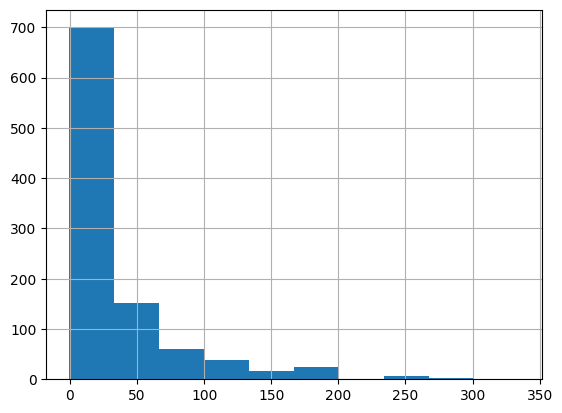

In [61]:
data.age.hist()

<Axes: >

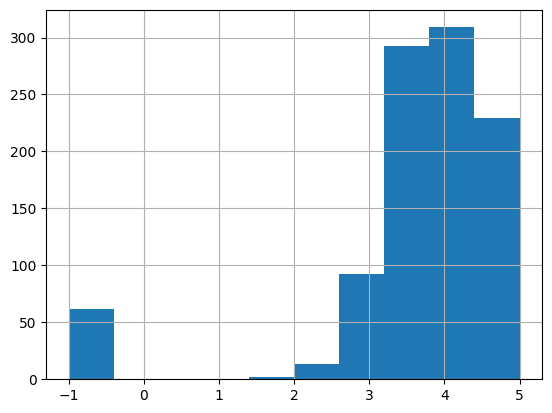

In [62]:
data.Rating.hist()


<Axes: xlabel='job_state'>

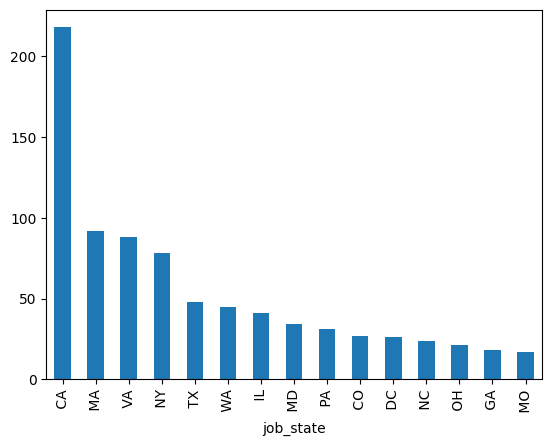

In [63]:
data.job_state.value_counts()[:15].plot(kind = 'bar')


In [64]:
numeric_data = data.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_data.corr()
print(correlation_matrix)


              Rating   Founded  min_salary  max_salary  avg_salary  \
Rating      1.000000  0.390460   -0.042775   -0.032203   -0.037977   
Founded     0.390460  1.000000   -0.082834   -0.072586   -0.079568   
min_salary -0.042775 -0.082834    1.000000    0.869927    0.956831   
max_salary -0.032203 -0.072586    0.869927    1.000000    0.975714   
avg_salary -0.037977 -0.079568    0.956831    0.975714    1.000000   
same_state  0.116271  0.167790   -0.022102   -0.011422   -0.016548   
age         0.097279  0.310521    0.030041    0.029143    0.030518   
python_yn  -0.035982 -0.064102    0.044367    0.055074    0.052163   
excel       0.032543  0.054014   -0.065241   -0.061509   -0.065227   

            same_state       age  python_yn     excel  
Rating        0.116271  0.097279  -0.035982  0.032543  
Founded       0.167790  0.310521  -0.064102  0.054014  
min_salary   -0.022102  0.030041   0.044367 -0.065241  
max_salary   -0.011422  0.029143   0.055074 -0.061509  
avg_salary   -0.016

<Axes: >

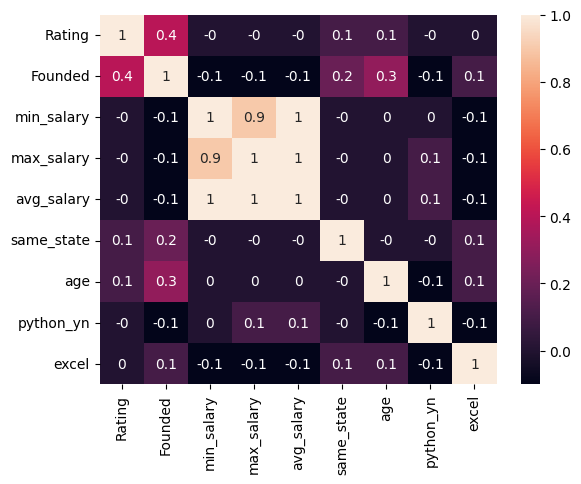

In [65]:
sns.heatmap(data = round(numeric_data.corr() ,1) , annot=True)


<Axes: ylabel='count'>

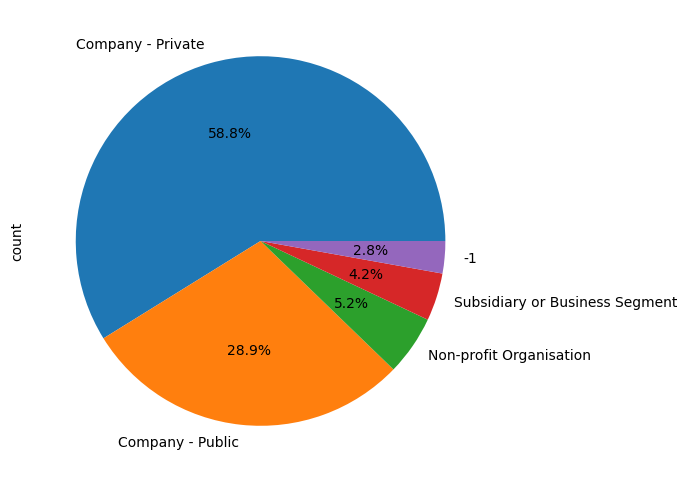

In [66]:
plt.figure(figsize=(12,6))
data['Type of ownership'].value_counts()[:5].plot(kind = 'pie' , autopct='%1.1f%%')

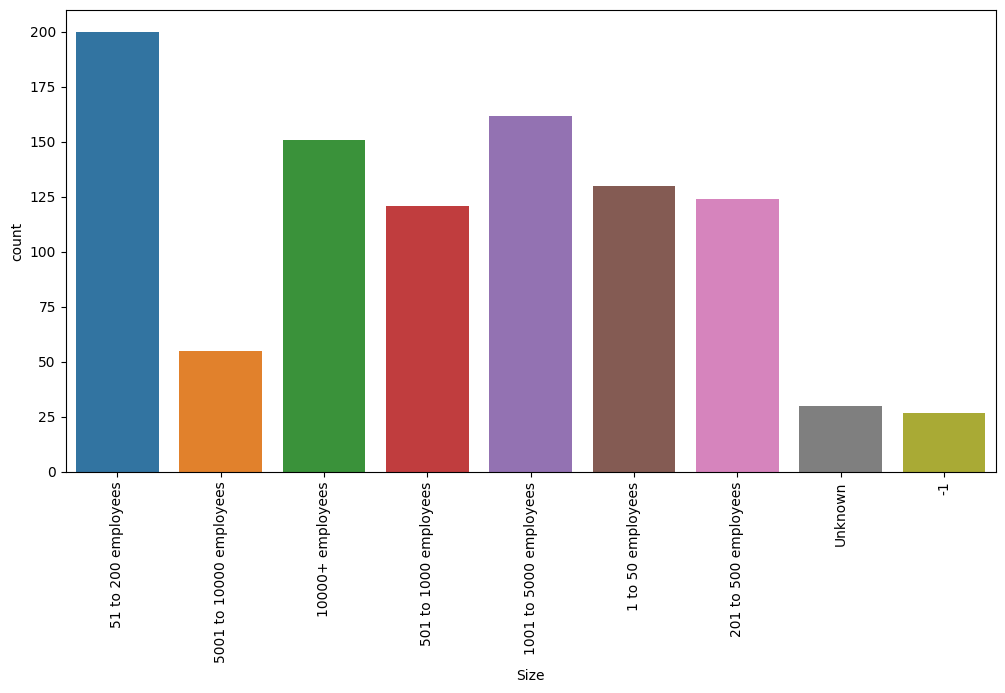

In [67]:
plt.figure(figsize=(12,6))
sns.countplot(data = data , x = 'Size')
plt.xticks(rotation = 90)
plt.show()

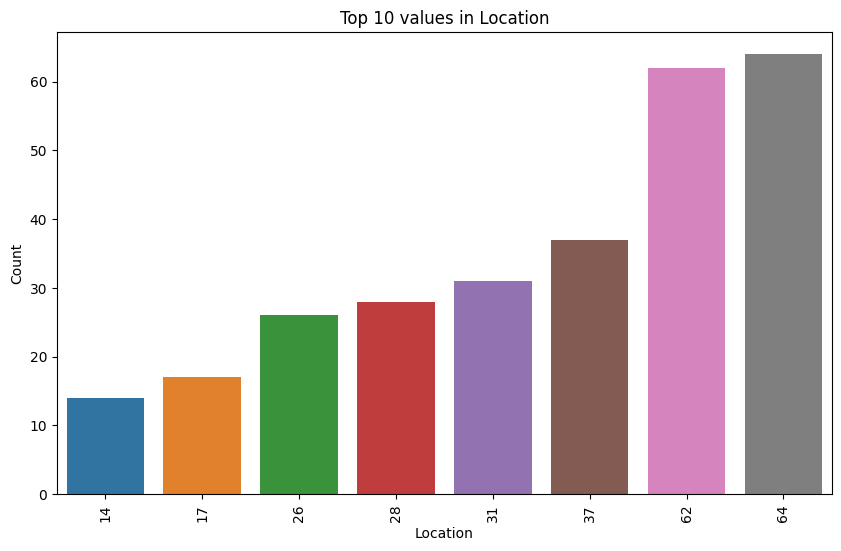

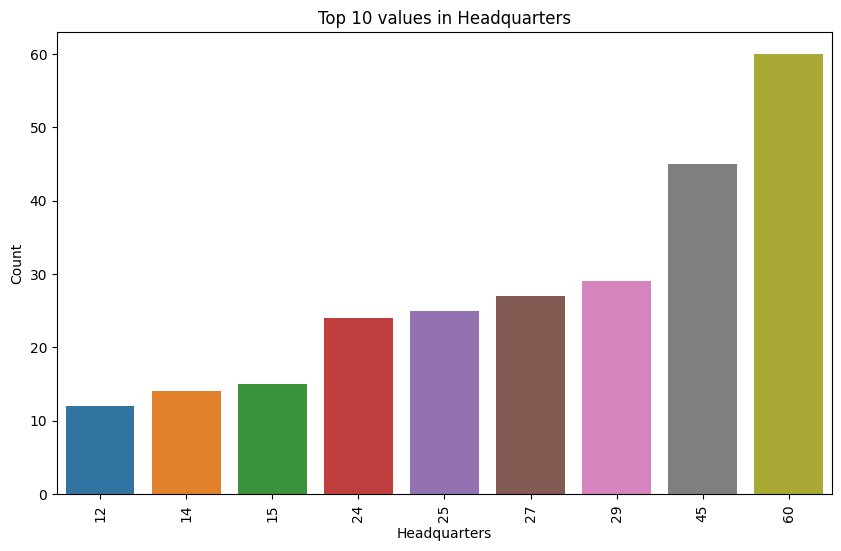

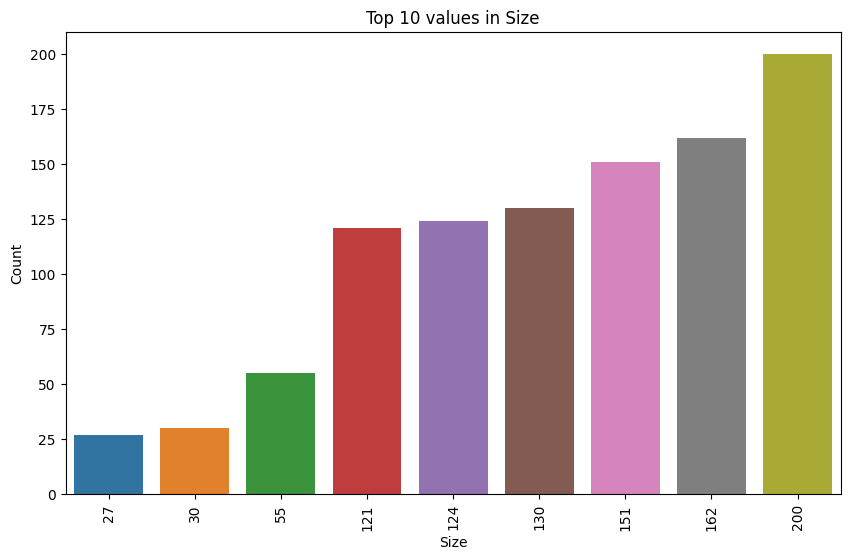

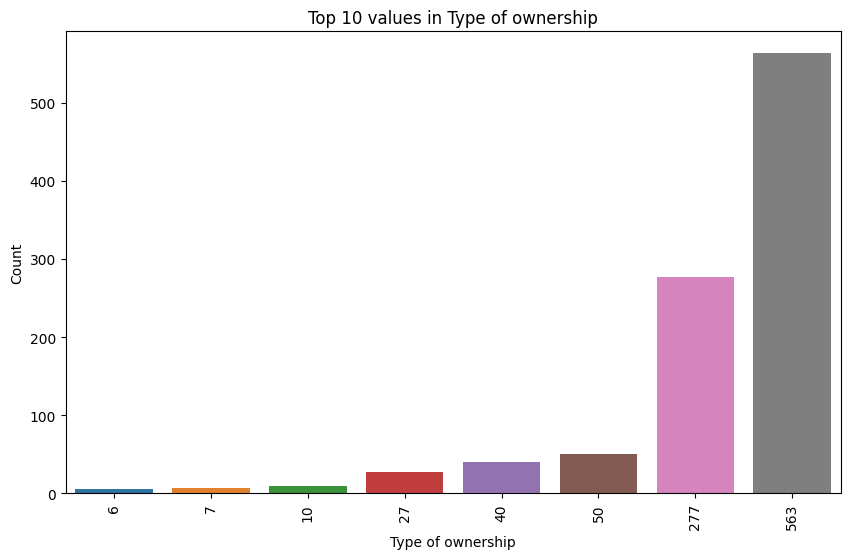

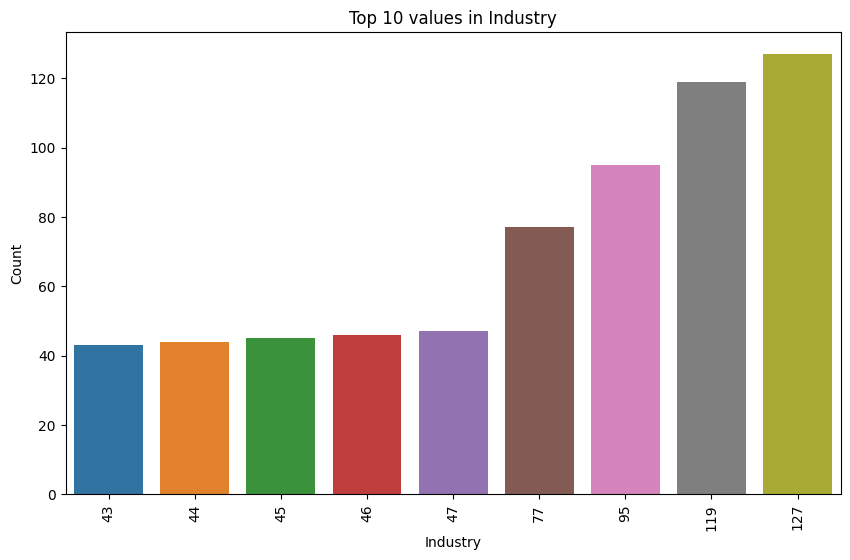

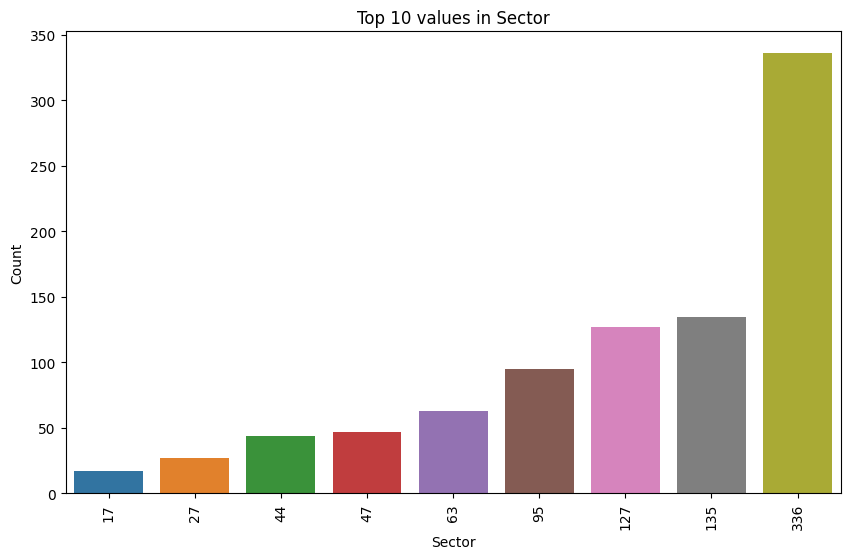

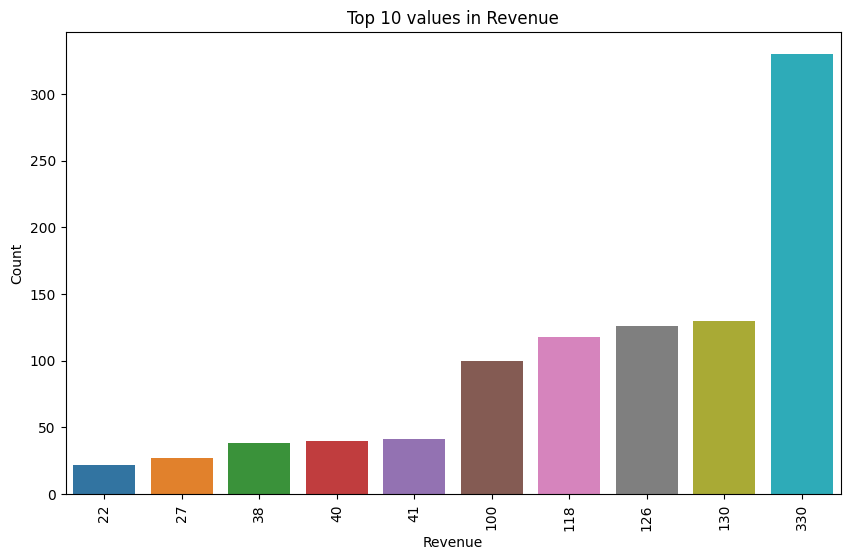

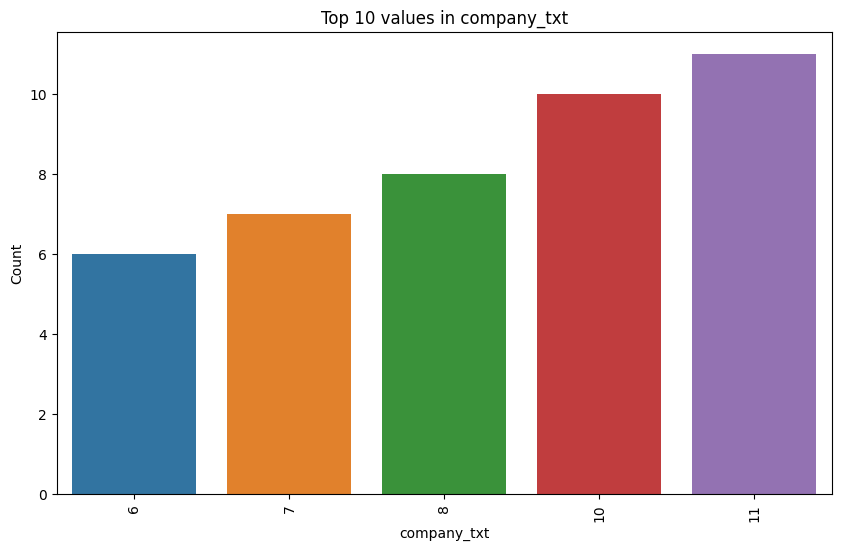

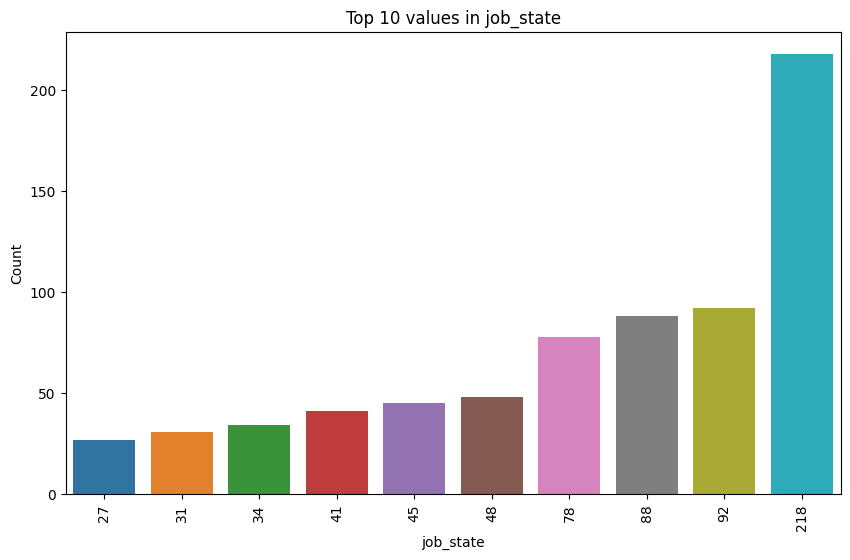

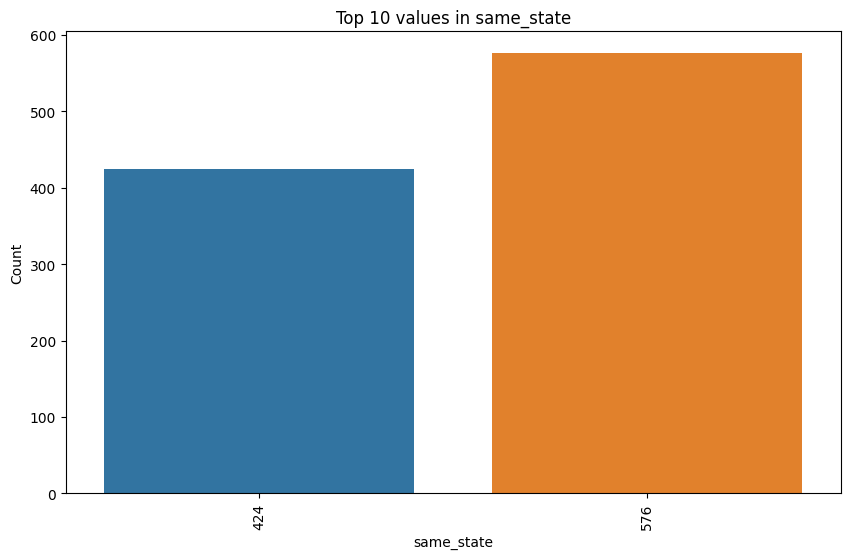

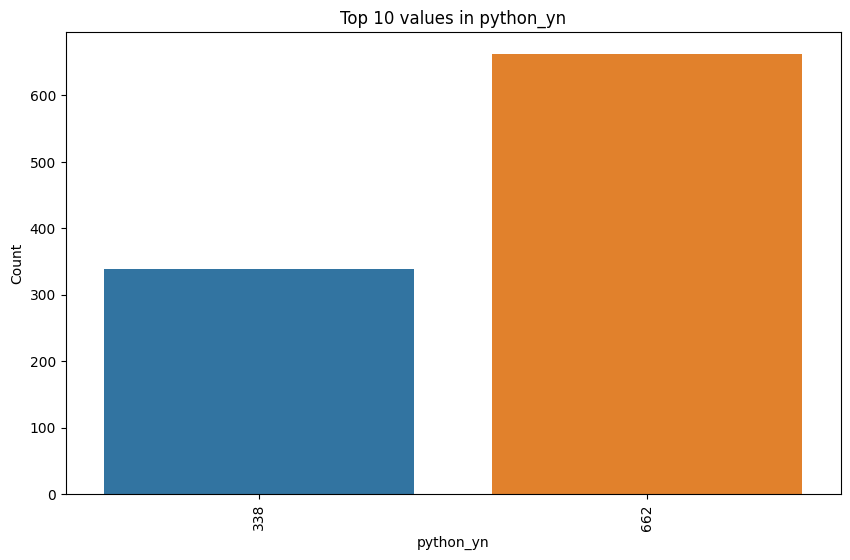

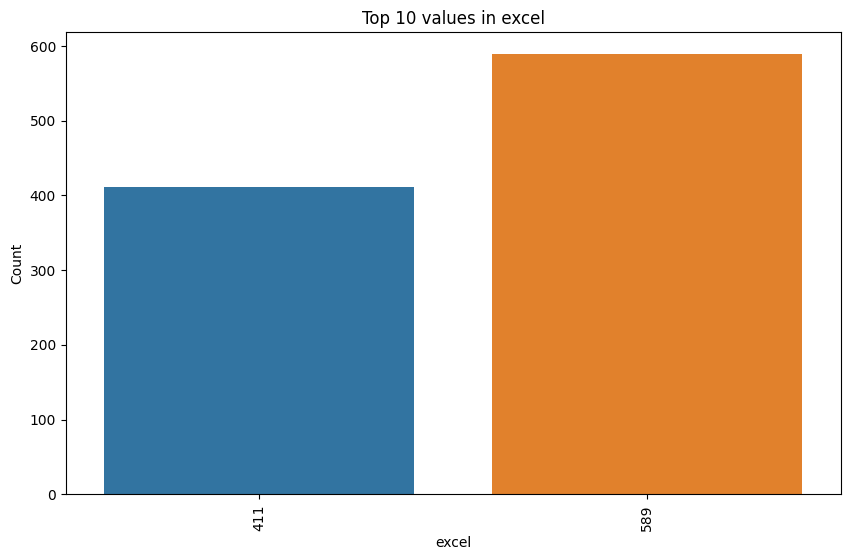

In [68]:

df_cat = data[['Location', 'Headquarters', 'Size','Type of ownership', 'Industry', 'Sector', 'Revenue', 'company_txt', 'job_state','same_state', 'python_yn', 
       'excel']]
for i in df_cat.columns:
    cat_num = df_cat[i].value_counts()
    plt.figure(figsize=(10, 6))  
    chart = sns.barplot(x=cat_num[cat_num.index[:10]], y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.title(f'Top 10 values in {i}')  
    plt.xlabel(i)  
    plt.ylabel('Count')  
    plt.show()

<Axes: xlabel='min_salary', ylabel='Rating'>

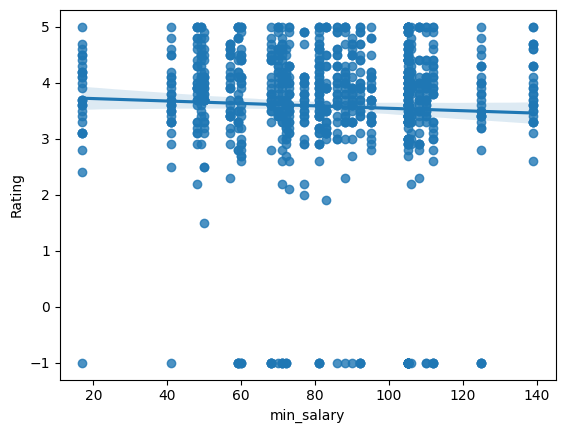

In [69]:
sns.regplot(data = data , y = 'Rating' , x = data.min_salary)


<Axes: xlabel='max_salary', ylabel='Rating'>

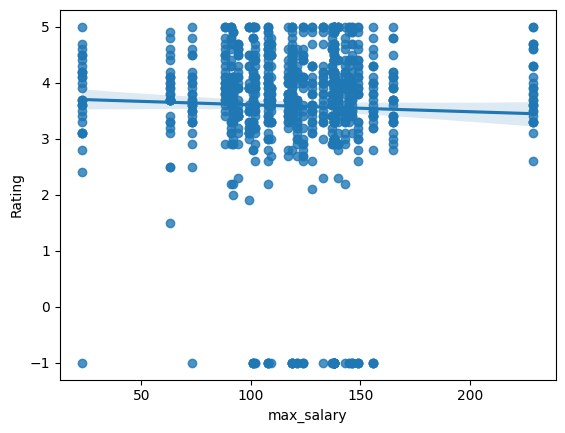

In [70]:
sns.regplot(data = data , y = 'Rating' , x = data.max_salary)

sns.regplot(data = data , y = 'Rating' , x = data.avg_salary)
